# DCT Laboratory — Volume I, Chapter 9
## Enterprise State Architecture
**Seed `26109`** · Companion to the chapter and AXIOM Module **AXIOM-09**

The state vector gets its wiring diagram: **which coordinates depend on which**.
Six components — Treasury, Operations, Technology, Sales, HR, Risk — a weighted
dependency graph, its topology metrics, a shock propagated through it, and path
counting via matrix powers. Mirrored in `DCT_V1_Ch09_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26109
NODES = ["Treasury","Operations","Technology","Sales","HR","Risk"]
# W[i,j] = strength with which a shock to j impacts i (column-source convention)
W = np.array([
 #  Tre  Ops  Tec  Sal  HR   Rsk
 [0.00,0.30,0.10,0.40,0.00,0.20],  # Treasury
 [0.10,0.00,0.45,0.20,0.25,0.00],  # Operations
 [0.15,0.05,0.00,0.00,0.20,0.00],  # Technology
 [0.00,0.35,0.30,0.00,0.10,0.00],  # Sales
 [0.05,0.10,0.00,0.00,0.00,0.00],  # HR
 [0.20,0.15,0.25,0.15,0.05,0.00],  # Risk
])
ADJ = (W > 0).astype(int)

def density():
    n = len(NODES)
    return ADJ.sum()/(n*(n-1))

def propagate(shock_node="Technology", rounds=3, size=10.0):
    e = np.zeros(6); e[NODES.index(shock_node)] = size
    impacts = [e]
    for _ in range(rounds):
        impacts.append(W @ impacts[-1])
    return np.array(impacts)          # (rounds+1, 6)

def paths_len3(src="Technology", dst="Treasury"):
    A3 = np.linalg.matrix_power(ADJ, 3)
    return int(A3[NODES.index(dst), NODES.index(src)])

def reference_values():
    imp = propagate()
    cum = imp[1:].sum(axis=0)         # cumulative over rounds 1..3
    return {
        "density":         round(float(density()), 4),
        "out_degree_tech": int(ADJ[:, NODES.index("Technology")].sum()),
        "ops_round1":      round(float(imp[1, NODES.index("Operations")]), 4),
        "treasury_round2": round(float(imp[2, NODES.index("Treasury")]), 4),
        "cum_impact_total":round(float(cum.sum()), 4),
        "cum_impact_risk": round(float(cum[NODES.index("Risk")]), 4),
        "paths3_tech_treasury": paths_len3(),
        "spectral_radius_W":   round(float(max(abs(np.linalg.eigvals(W)))), 4),
    }
if __name__ == "__main__":
    [print(f"{k:24s} {v}") for k,v in reference_values().items()]

density                  0.7
out_degree_tech          4
ops_round1               4.5
treasury_round2          3.05
cum_impact_total         22.8738
cum_impact_risk          4.895
paths3_tech_treasury     8
spectral_radius_W        0.625


## Panel 1 — The dependency graph, as a matrix
$W_{ij}$ = the strength with which a shock to component $j$ impacts component
$i$. The unweighted skeleton `ADJ` is the **Enterprise Topology** (Def.); the
Dependency Graph Is Behaviorally Minimal and Sufficient (Prop.) — it carries
exactly the propagation structure, nothing else.

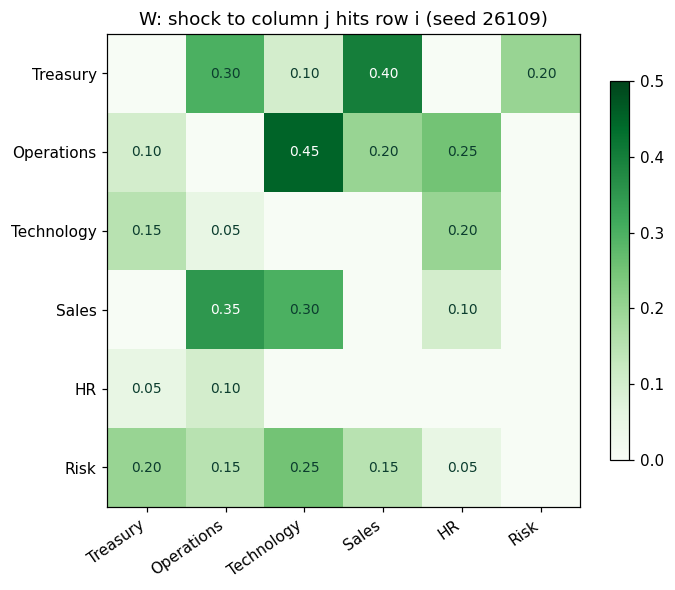

density: 0.7000   out-degree(Technology): 4
spectral radius of W: 0.6250  (<1: shocks die out)


In [2]:
fig, ax = plt.subplots(figsize=(6.6,5.4))
im = ax.imshow(W, cmap="Greens", vmin=0, vmax=0.5)
ax.set_xticks(range(6), NODES, rotation=35, ha="right")
ax.set_yticks(range(6), NODES)
for i in range(6):
    for j in range(6):
        if W[i,j]>0: ax.text(j, i, f"{W[i,j]:.2f}", ha="center", va="center",
                             color="white" if W[i,j]>0.3 else "#0B3D2E", fontsize=9)
ax.set(title="W: shock to column j hits row i (seed 26109)")
plt.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()
print(f"density: {density():.4f}   out-degree(Technology): {ADJ[:,NODES.index('Technology')].sum()}")
print(f"spectral radius of W: {max(abs(np.linalg.eigvals(W))):.4f}  (<1: shocks die out)")

## Panel 2 — A shock, propagated
Size-10 shock to **Technology**; rounds are $s_k = W s_{k-1}$ (Structural
Dependency Theorem: propagation follows the graph, and only the graph).
Operations takes 4.5 in round 1; Treasury takes 3.05 in round 2 — **two hops
from a technology event to a funding event**, along edges anyone could have
read off the matrix in advance.

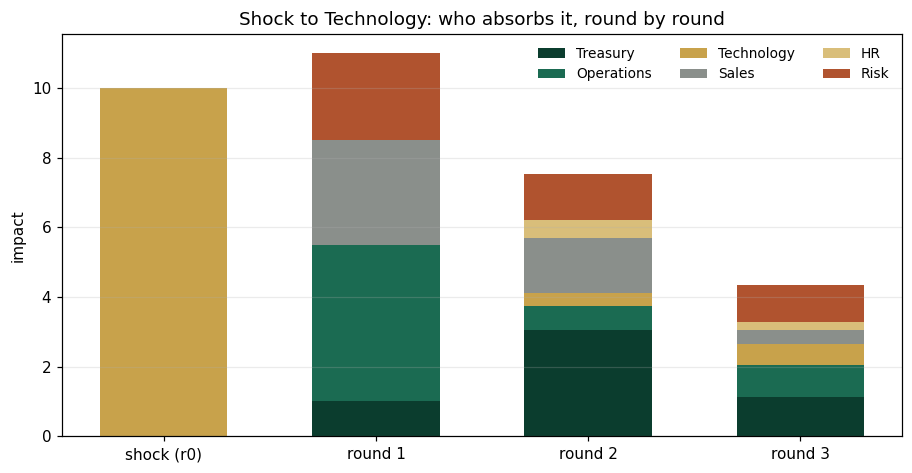

cumulative impact on Treasury      5.1925
cumulative impact on Operations    6.1138
cumulative impact on Technology    0.9675
cumulative impact on Sales         4.9825
cumulative impact on HR            0.7225
cumulative impact on Risk          4.8950
total propagated impact (3 rounds): 22.8738


In [3]:
imp = propagate()
fig, ax = plt.subplots(figsize=(8.4,4.4))
bottom = np.zeros(4)
colors = ["#0B3D2E","#1B6B52","#C8A24B","#8A8F8B","#D9BE7A","#B0532F"]
for i,(nm,c) in enumerate(zip(NODES,colors)):
    ax.bar(range(4), imp[:,i], bottom=bottom, label=nm, color=c, width=.6)
    bottom += imp[:,i]
ax.set_xticks(range(4), ["shock (r0)","round 1","round 2","round 3"])
ax.set(ylabel="impact", title="Shock to Technology: who absorbs it, round by round")
ax.legend(frameon=False, ncols=3, fontsize=9); ax.grid(alpha=.25, axis="y")
plt.tight_layout(); plt.show()
cum = imp[1:].sum(axis=0)
for nm, v in zip(NODES, cum): print(f"cumulative impact on {nm:12s} {v:7.4f}")
print(f"total propagated impact (3 rounds): {cum.sum():.4f}")

## Panel 3 — Paths and complexity
$(A^3)_{ij}$ counts length-3 dependency paths — **8 distinct three-hop routes**
from Technology to Treasury. Complexity Grows with Interdependence (Prop.):
density 0.70 on six nodes already generates this routing richness, which is
exactly what makes architectural analysis non-optional at enterprise scale.

In [4]:
A3 = np.linalg.matrix_power(ADJ, 3)
print("A^3 (length-3 path counts):")
print("            " + "  ".join(f"{n[:4]:>5s}" for n in NODES))
for i,nm in enumerate(NODES):
    print(f"{nm:12s}" + "  ".join(f"{A3[i,j]:5d}" for j in range(6)))
print(f"\npaths of length 3, Technology → Treasury: {paths_len3()}")

A^3 (length-3 path counts):
             Trea   Oper   Tech   Sale     HR   Risk
Treasury       10     12      8      6      8      3
Operations      9      8      8      7      8      2
Technology      6      8      7      5      7      2
Sales           5      7      6      5      4      3
HR              5      7      5      3      6      1
Risk           11     12     10      8     10      3

paths of length 3, Technology → Treasury: 8


## Validation — agrees with `DCT_V1_Ch09_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"density":0.7,"out_degree_tech":4,"ops_round1":4.5,"treasury_round2":3.05,
 "cum_impact_total":22.8738,"cum_impact_risk":4.895,"paths3_tech_treasury":8,"spectral_radius_W":0.625}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:24s} {ref[k]}")
print("\nAll checkpoints agree — seed 26109.")

PASS  density                  0.7
PASS  out_degree_tech          4
PASS  ops_round1               4.5
PASS  treasury_round2          3.05
PASS  cum_impact_total         22.8738
PASS  cum_impact_risk          4.895
PASS  paths3_tech_treasury     8
PASS  spectral_radius_W        0.625

All checkpoints agree — seed 26109.


**Next**: Exercises 9.9–9.12 (Part C) rewire the graph and re-propagate; AXIOM-09's architecture canvas makes the matrix draggable. Solutions: IM Ch. 9.